In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product

## Clean signal

In [3]:
rng = np.random.default_rng(42)

n = 1000
t = np.linspace(0, 1, n)

sigma = 0.10

window_sizes = [451, 231, 151, 107, 75, 53, 37, 27, 19, 13]
kmax = len(window_sizes)

contamination_probs = [0.0, 0.01, 0.05, 0.10, 0.30, 0.50, 0.60]
contamination_scales = [0.5, 1.0, 2.0, 4.0]

n_repeats = 5

In [4]:
def gen_signal(t):
    slow = 0.6 * np.sin(2 * np.pi * t)
    medium = 0.25 * np.sin(12 * np.pi * t)
    bump = 0.8 * np.exp(-((t - 0.55) ** 2) / (2 * 0.015 ** 2))
    trend = 0.5 * (t - 0.5)

    x = slow + medium + bump + trend

    components = {
        "slow": slow,
        "medium": medium,
        "bump": bump,
        "trend": trend
    }

    return x, components

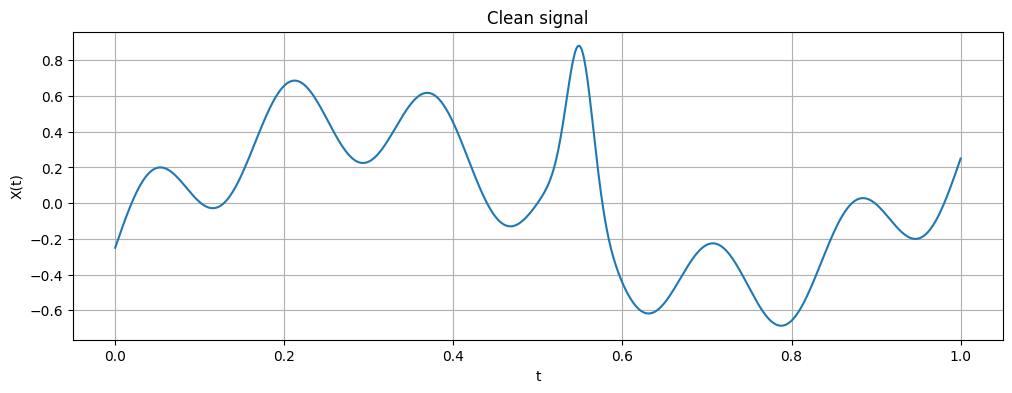

In [5]:
x_clean, true_components = gen_signal(t)

plt.figure(figsize=(12, 4))
plt.plot(t, x_clean)
plt.title("Clean signal")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.grid(True)
plt.show()

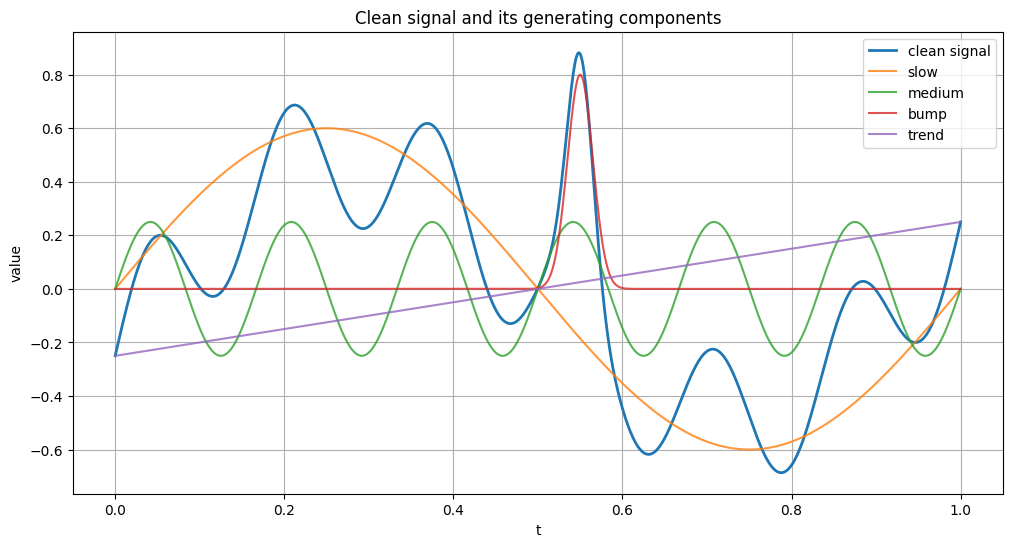

In [6]:
plt.figure(figsize=(12, 6))

plt.plot(t, x_clean, label="clean signal", linewidth=2)

for name, component in true_components.items():
    plt.plot(t, component, label=name, alpha=0.8)

plt.title("Clean signal and its generating components")
plt.xlabel("t")
plt.ylabel("value")
plt.legend()
plt.grid(True)
plt.show()

## Exponential contamination

In [7]:
def generate_observation(
    x,
    sigma=0.1,
    contamination_prob=0.05,
    contamination_scale=2.0,
    centered_contamination=False,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    gaussian_noise = rng.normal(loc=0.0, scale=sigma, size=len(x))

    contamination_mask = rng.random(len(x)) < contamination_prob
    exponential_noise = rng.exponential(scale=contamination_scale, size=len(x))

    if centered_contamination:
        exponential_noise = exponential_noise - contamination_scale

    contamination = contamination_mask * exponential_noise

    y = x + gaussian_noise + contamination

    return y, {
        "gaussian_noise": gaussian_noise,
        "contamination": contamination,
        "contamination_mask": contamination_mask
    }

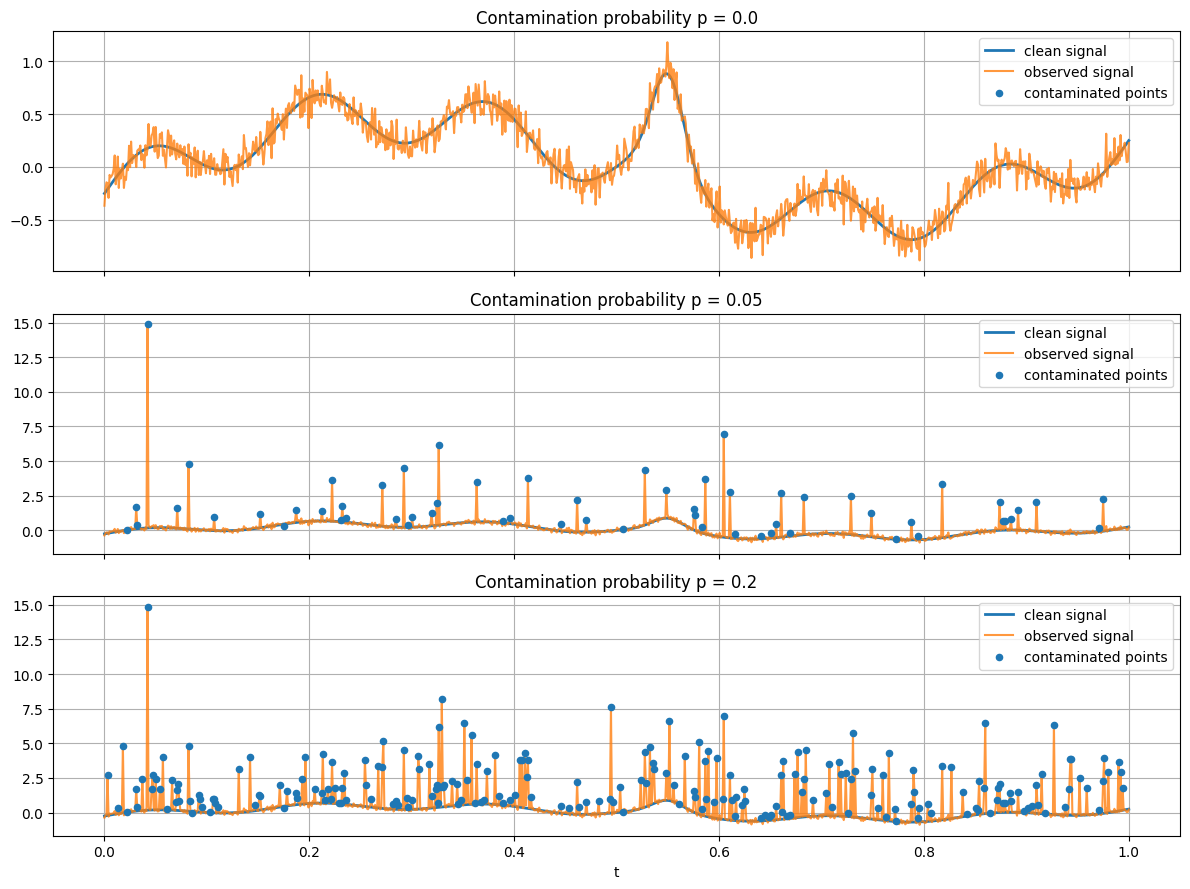

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

example_probs = [0.0, 0.05, 0.20]
example_scale = 2.0

for ax, p in zip(axes, example_probs):
    y, noise_info = generate_observation(
        x_clean,
        sigma=sigma,
        contamination_prob=p,
        contamination_scale=example_scale,
        rng=np.random.default_rng(100),
    )

    ax.plot(t, x_clean, label="clean signal", linewidth=2)
    ax.plot(t, y, label="observed signal", alpha=0.8)

    mask = noise_info["contamination_mask"]
    ax.scatter(
        t[mask],
        y[mask],
        s=20,
        label="contaminated points",
        zorder=3,
    )

    ax.set_title(f"Contamination probability p = {p}")
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("t")
plt.tight_layout()
plt.show()

## Mean and Median filtering

In [9]:
def epanechnikov_weights(window_size):
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")

    radius = window_size // 2

    if radius == 0:
        return np.array([1.0])

    offsets = np.arange(-radius, radius + 1)
    u = offsets / radius

    weights = 0.75 * np.maximum(0, 1 - np.abs(u)) ** 2

    weights = weights / weights.sum()

    return weights

In [10]:
def local_mean_filter(y, window_size, boundary="wrap"):
    weights = epanechnikov_weights(window_size)
    radius = window_size // 2

    y_padded = np.pad(y, pad_width=radius, mode=boundary)

    out = np.empty_like(y, dtype=float)

    for i in range(len(y)):
        window = y_padded[i : i + window_size]
        out[i] = np.sum(weights * window)

    return out

def local_median_filter(y, window_size, boundary="wrap"):
    radius = window_size // 2

    y_padded = np.pad(y, pad_width=radius, mode=boundary)

    out = np.empty_like(y, dtype=float)

    for i in range(len(y)):
        window = y_padded[i : i + window_size]
        out[i] = np.median(window)

    return out

In [11]:
def weighted_median(values, weights):
    order = np.argsort(values)
    sorted_values = values[order]
    sorted_weights = weights[order]

    cumulative_weight = np.cumsum(sorted_weights)
    cutoff = 0.5 * sorted_weights.sum()

    idx = np.searchsorted(cumulative_weight, cutoff)

    return sorted_values[idx]

def local_weighted_median_filter(y, window_size, boundary="wrap"):
    weights = epanechnikov_weights(window_size)
    radius = window_size // 2

    y_padded = np.pad(y, pad_width=radius, mode=boundary)

    out = np.empty_like(y, dtype=float)

    for i in range(len(y)):
        window = y_padded[i : i + window_size]
        out[i] = weighted_median(window, weights)

    return out

## IMF decomposition

In [12]:
def imf_decomposition(y, window_sizes, filter_fn, boundary="wrap"):
    residual = y.astype(float).copy()
    imfs = []

    for window_size in window_sizes:
        s_k = filter_fn(residual, window_size, boundary=boundary)
        imfs.append(s_k)
        residual = residual - s_k

    return {
        "imfs": np.array(imfs),
        "residual": residual,
        "reconstruction": np.array(imfs).sum(axis=0) + residual,
    }

In [13]:
def linear_imf(y, window_sizes):
    return imf_decomposition(
        y,
        window_sizes=window_sizes,
        filter_fn=local_mean_filter,
    )


def median_imf(y, window_sizes):
    return imf_decomposition(
        y,
        window_sizes=window_sizes,
        filter_fn=local_median_filter,
    )

def weighted_median_imf(y, window_sizes):
    return imf_decomposition(
        y,
        window_sizes=window_sizes,
        filter_fn=local_weighted_median_filter,
    )

## Reconstruction check

In [14]:
y_example, _ = generate_observation(
    x_clean,
    sigma=sigma,
    contamination_prob=0.05,
    contamination_scale=2.0,
    rng=np.random.default_rng(123),
)

linear_result = linear_imf(y_example, window_sizes)
median_result = median_imf(y_example, window_sizes)

linear_reconstruction_error = np.max(
    np.abs(linear_result["reconstruction"] - y_example)
)

median_reconstruction_error = np.max(
    np.abs(median_result["reconstruction"] - y_example)
)

print("linear reconstruction max error:", linear_reconstruction_error)
print("median reconstruction max error:", median_reconstruction_error)

linear reconstruction max error: 8.881784197001252e-16
median reconstruction max error: 8.881784197001252e-16


In [23]:
p_example = 0.05
scale_example = 2.0

y_example, noise_info = generate_observation(
    x_clean,
    sigma=sigma,
    contamination_prob=p_example,
    contamination_scale=scale_example,
    rng=np.random.default_rng(777),
)

linear_result = linear_imf(y_example, window_sizes)
median_result = median_imf(y_example, window_sizes)
weighted_median_result = weighted_median_imf(y_example, window_sizes)

### Plot contaminated signal

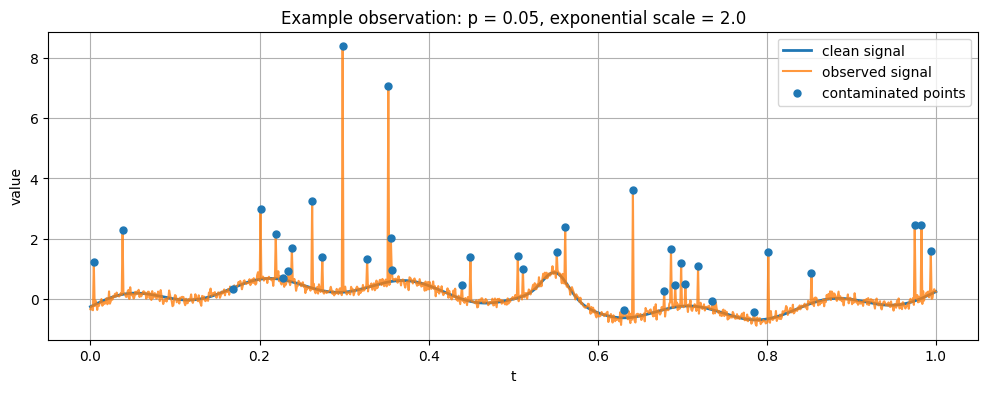

In [24]:
mask = noise_info["contamination_mask"]

plt.figure(figsize=(12, 4))

plt.plot(t, x_clean, label="clean signal", linewidth=2)
plt.plot(t, y_example, label="observed signal", alpha=0.8)

plt.scatter(
    t[mask],
    y_example[mask],
    s=25,
    label="contaminated points",
    zorder=3,
)

plt.title(
    f"Example observation: p = {p_example}, exponential scale = {scale_example}"
)
plt.xlabel("t")
plt.ylabel("value")
plt.legend()
plt.grid(True)
plt.show()

### Plot first IMFs

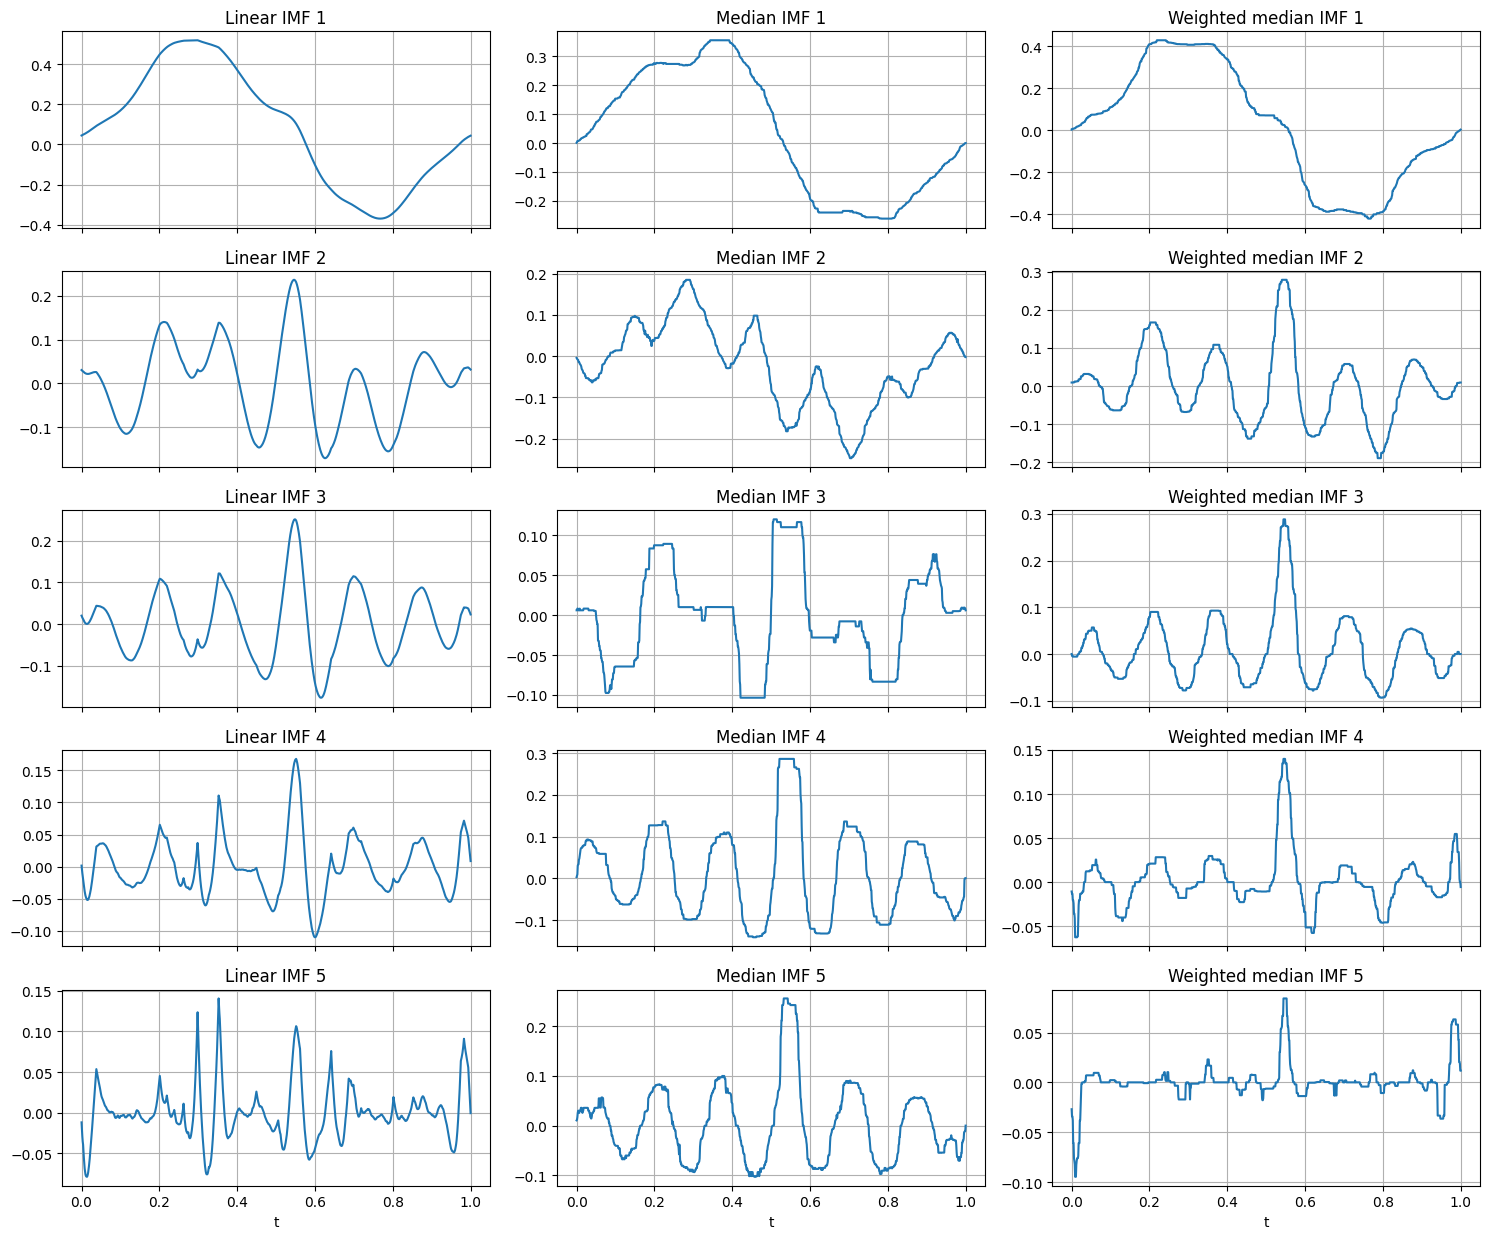

In [25]:
n_show = 5

fig, axes = plt.subplots(n_show, 3, figsize=(15, 2.5 * n_show), sharex=True)

for k in range(n_show):
    axes[k, 0].plot(t, linear_result["imfs"][k])
    axes[k, 0].set_title(f"Linear IMF {k + 1}")
    axes[k, 0].grid(True)

    axes[k, 1].plot(t, median_result["imfs"][k])
    axes[k, 1].set_title(f"Median IMF {k + 1}")
    axes[k, 1].grid(True)

    axes[k, 2].plot(t, weighted_median_result["imfs"][k])
    axes[k, 2].set_title(f"Weighted median IMF {k + 1}")
    axes[k, 2].grid(True)

axes[-1, 0].set_xlabel("t")
axes[-1, 1].set_xlabel("t")
axes[-1, 2].set_xlabel("t")

plt.tight_layout()
plt.show()

### Compare residuals

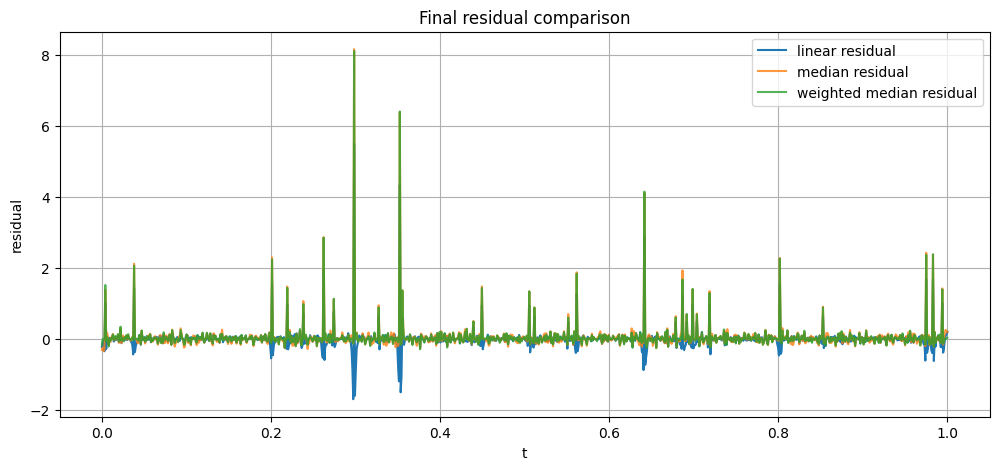

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(t, linear_result["residual"], label="linear residual")
plt.plot(t, median_result["residual"], label="median residual", alpha=0.8)
plt.plot(t, weighted_median_result["residual"], label="weighted median residual", alpha=0.8)

plt.title("Final residual comparison")
plt.xlabel("t")
plt.ylabel("residual")
plt.legend()
plt.grid(True)
plt.show()

### Clean-reference decompositions

In [27]:
linear_clean = linear_imf(x_clean, window_sizes)
median_clean = median_imf(x_clean, window_sizes)
weighted_median_clean = weighted_median_imf(x_clean, window_sizes)

### Metrics

In [28]:
def mse(a, b):
    return np.mean((a - b) ** 2)


def mae(a, b):
    return np.mean(np.abs(a - b))


def max_abs_error(a, b):
    return np.max(np.abs(a - b))


def summarize_decomposition_error(result_noisy, result_clean, method_name):
    rows = []

    imfs_noisy = result_noisy["imfs"]
    imfs_clean = result_clean["imfs"]

    for k in range(imfs_noisy.shape[0]):
        rows.append({
            "method": method_name,
            "component": f"imf_{k + 1}",
            "component_index": k + 1,
            "mse": mse(imfs_noisy[k], imfs_clean[k]),
            "mae": mae(imfs_noisy[k], imfs_clean[k]),
            "max_abs_error": max_abs_error(imfs_noisy[k], imfs_clean[k]),
        })

    rows.append({
        "method": method_name,
        "component": "residual",
        "component_index": len(window_sizes) + 1,
        "mse": mse(result_noisy["residual"], result_clean["residual"]),
        "mae": mae(result_noisy["residual"], result_clean["residual"]),
        "max_abs_error": max_abs_error(
            result_noisy["residual"],
            result_clean["residual"],
        ),
    })

    return rows

In [29]:
example_rows = []

example_rows.extend(
    summarize_decomposition_error(
        linear_result,
        linear_clean,
        method_name="linear_mean",
    )
)

example_rows.extend(
    summarize_decomposition_error(
        median_result,
        median_clean,
        method_name="median",
    )
)

example_rows.extend(
    summarize_decomposition_error(
        weighted_median_result,
        weighted_median_clean,
        method_name="weighted_median",
    )
)

example_error_df = pd.DataFrame(example_rows)

example_error_df

,method,component,component_index,mse,mae,max_abs_error
0,linear_mean,imf_1,1,0.003780,0.056032,0.121224
1,linear_mean,imf_2,2,0.000503,0.018212,0.065947
2,linear_mean,imf_3,3,0.000249,0.012031,0.053813
3,linear_mean,imf_4,4,0.000312,0.012589,0.085139
4,linear_mean,imf_5,5,0.000605,0.015846,0.135624
5,linear_mean,imf_6,6,0.000787,0.017112,0.198090
6,linear_mean,imf_7,7,0.001106,0.019572,0.287025
7,linear_mean,imf_8,8,0.001307,0.020543,0.377170
8,linear_mean,imf_9,9,0.001974,0.023173,0.542091
9,linear_mean,imf_10,10,0.003456,0.028161,0.811773


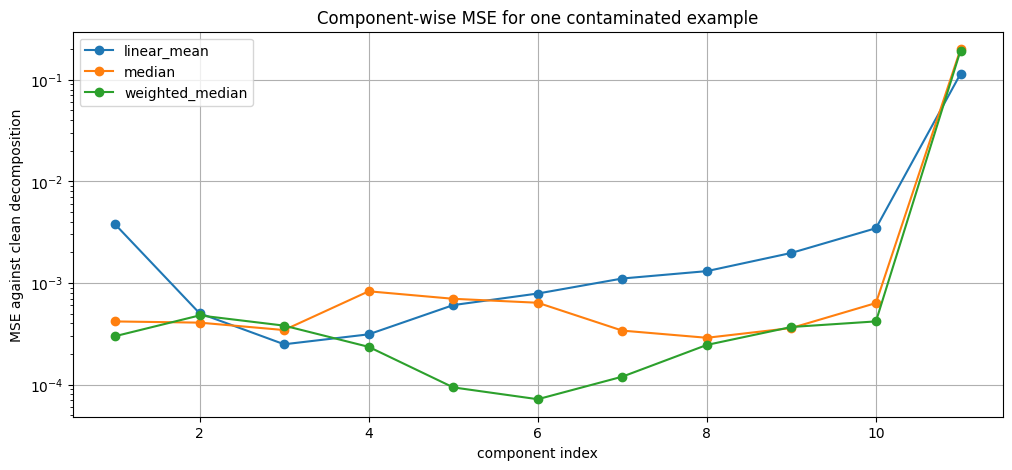

In [30]:
plt.figure(figsize=(12, 5))

for method_name, group in example_error_df.groupby("method"):
    plt.plot(
        group["component_index"],
        group["mse"],
        marker="o",
        label=method_name,
    )

plt.yscale("log")
plt.title("Component-wise MSE for one contaminated example")
plt.xlabel("component index")
plt.ylabel("MSE against clean decomposition")
plt.legend()
plt.grid(True)
plt.show()